# View BPMN of Each Fragment

**Prerequisite:** Notebook `02_quality_measurments.ipynb` must have been run first.
That creates the metrics file and the XES sub-log files per fragment.

This notebook loads those pre-exported XES files and displays the BPMN for each fragment's process model.

In [17]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append('../')

from IPython.display import display, HTML

from process_fragment_miner.utils import (
    parse_metrics_file,
    mine_fragment_from_xes,
    save_process_trees,
    get_xes_dir_and_base,
    get_fragments_by_labels_from_log,
    import_xes,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Configuration

In [18]:
# --- CONFIG ---
METRICS_PATH = "../data/processed/BPIC/BPIC12.xes.gz.pfm.metrics.txt"
LOG_PATH = "../data/raw/BPIC12.xes.gz"

# Methods to visualize (subset of: dk, heuristic, bigram, similarity)
# 'dk' is not in the metrics file but has XES sub-log files
# METHODS = ["dk", "heuristic", "bigram", "similarity"]
METHODS = [ "heuristic"]
# Noise threshold for inductive miner
NOISE_THRESHOLD = 0.0

# Derive XES directory and filename base from the metrics path
XES_DIR, FILENAME_BASE = get_xes_dir_and_base(METRICS_PATH)
print(f"XES dir: {XES_DIR}")
print(f"Base:    {FILENAME_BASE}")

XES dir: ../data/processed/BPIC\xes
Base:    BPIC12.xes.gz


## 2. Get Fragments per Method

Loads fragment activity lists from the metrics file (or computes 'dk' from the log).

In [19]:
fragments_by_method = {}

# Load non-dk methods from metrics file
if os.path.exists(METRICS_PATH):
    parsed = parse_metrics_file(METRICS_PATH)
    for m in METHODS:
        if m in parsed:
            fragments_by_method[m] = parsed[m]
    print(f"Loaded from: {METRICS_PATH}")
    for m, data in fragments_by_method.items():
        print(f"  {m}: score={data['score']:.4f}, {len(data['fragments'])} fragments")
else:
    print(f"Not found: {METRICS_PATH}")
    print("Run 02_quality_measurments.ipynb first.")

# Compute 'dk' fragments from the log (not stored in metrics file)
if "dk" in METHODS and "dk" not in fragments_by_method:
    if LOG_PATH.startswith("../"):
        event_log = import_xes(logs_dir="..", filename=LOG_PATH[3:])
    else:
        from process_fragment_miner.adapters import load_event_log
        event_log = load_event_log(LOG_PATH)
    dk_frags = get_fragments_by_labels_from_log(event_log)
    fragments_by_method["dk"] = {"score": 0.0, "fragments": dk_frags}
    print(f"  dk: {len(dk_frags)} fragments (computed from log labels)")

if not fragments_by_method:
    print("No methods available.")

Loaded from: ../data/processed/BPIC/BPIC12.xes.gz.pfm.metrics.txt
  heuristic: score=3.2507, 5 fragments


## 3. View BPMN + Process Tree for Each Fragment
For each fragment, we load the pre-exported XES sub-log file
(created by `export_xes_by_fragments()` during evaluation) and show its BPMN and process tree.

parsing log, completed traces ::   0%|          | 0/13087 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/2 [00:00<?, ?it/s]

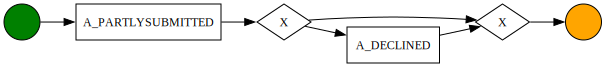

parsing log, completed traces ::   0%|          | 0/5015 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/419 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/2261 [00:00<?, ?it/s]

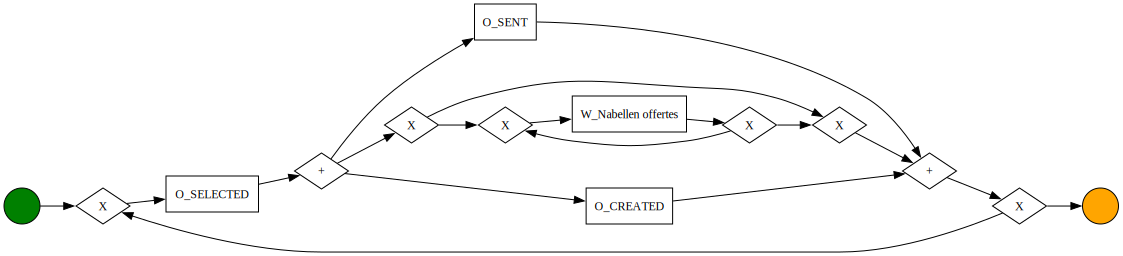

parsing log, completed traces ::   0%|          | 0/3254 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/42 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/86 [00:00<?, ?it/s]

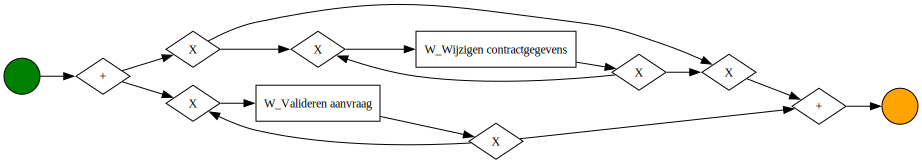

parsing log, completed traces ::   0%|          | 0/2662 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/226 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/336 [00:00<?, ?it/s]

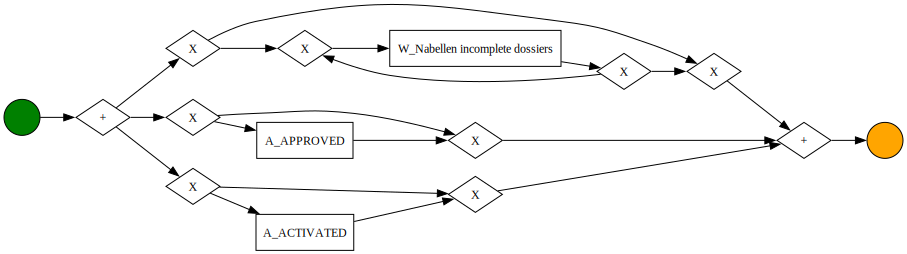

parsing log, completed traces ::   0%|          | 0/13087 [00:00<?, ?it/s]

aligning log, completed variants ::   0%|          | 0/1034 [00:00<?, ?it/s]

computing precision with alignments, completed variants ::   0%|          | 0/2201 [00:00<?, ?it/s]

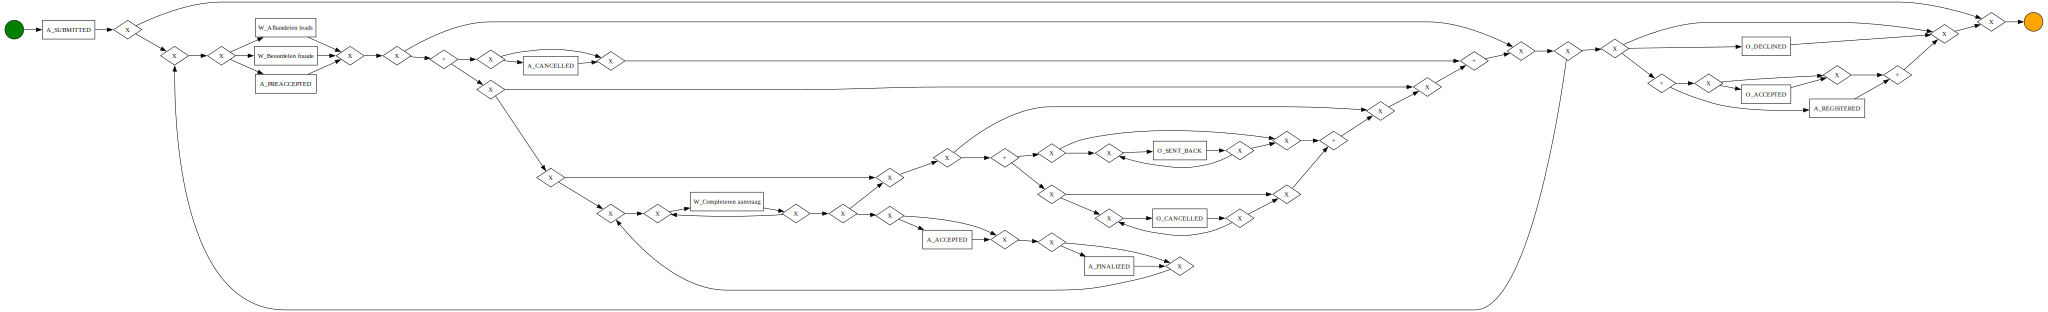

In [20]:
# Collect process trees for saving
all_process_trees = {}

for method, data in fragments_by_method.items():
    fragments = data["fragments"]
    display(HTML(f"<h2>Method: {method} (score={data['score']:.4f})</h2>"))
    tree_entries = []

    for i, fragment_activities in enumerate(fragments):
        xes_path = os.path.join(XES_DIR, f"{FILENAME_BASE}.{i}.{method}.xes.gz")

        if not os.path.exists(xes_path):
            display(HTML(f"<h3>Fragment {i} ({len(fragment_activities)} activities)</h3>"))
            display(HTML(f"<b>XES file not found:</b> {xes_path}"))
            display(HTML("<hr>"))
            continue

        display(HTML(f"<h3>Fragment {i} ({len(fragment_activities)} activities)</h3>"))
        display(HTML(f"<b>Activities:</b> {', '.join(fragment_activities)}"))
        display(HTML(f"<i>Sub-log:</i> {os.path.basename(xes_path)}"))

        result = mine_fragment_from_xes(xes_path, noise_threshold=NOISE_THRESHOLD)

        if result['process_tree'] is not None:
            tree_str = result['process_tree'].to_string()
            display(HTML(f"<b>Process Tree:</b> <pre style='font-size:11px'>{tree_str}</pre>"))
            tree_entries.append((i, tree_str))

        if result['metrics']:
            m = result['metrics']
            display(HTML(
                f"<b>Metrics:</b> "
                f"Fitness={m['fi']:.4f}, Precision={m['pr']:.4f}, "
                f"F1={m['F1']:.4f}, CFC={m['CFC']}, Size={m['size']}"
            ))

        if result['gviz'] is not None:
            display(result['gviz'])
        else:
            display(HTML("<i>No process model (sub-log is empty).</i>"))

        display(HTML("<hr>"))

    all_process_trees[method] = tree_entries

# Save process trees to a text file alongside the metrics file
trees_path = METRICS_PATH.replace('.pfm.metrics.txt', '.process_trees.txt')
save_process_trees(all_process_trees, trees_path)
print(f"Process trees saved to: {trees_path}")